## Creacón de Dataframe y limpieza del mismo

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('titanic/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Vamos a limpiar algunos datos que creo que nos dan igual.


In [3]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Veo que hay muchos NA en age y cabina. Si eliminase todas las filas de NA me quedaría con muy pocos datos 
para entreanar el modelo. Entonces decirdo quitar age y cabin para poder eliminar solo las 2 filas de embarked que pienso que sí se van a tener que eliminar

In [4]:
df_limpio = df.drop('Cabin', axis=1)

# Sin embargo, si me quedo sin la edad de los pasajeros, pierdo gran parte de la información
# relleno los NA con la media
edad_media = df_limpio['Age'].mean()
df_limpio['Age'] = df_limpio['Age'].fillna(edad_media)
df_limpio = df_limpio.dropna(subset=['Embarked'])

In [5]:
df_limpio.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Ahora tenego todas las columnas sin ningun tipo de NA. Entonces, quiero ver las correlaciones de las variables de mi conjunto de datos con respecto a mi variable Survived. Esto lo hago para saber cuales pueden resultarle más utiles al modelo para predecir con mayor exactitud

Eliminamos el nombre, y el número de tikets
Luego, pasamos Embarked por un ordinalencoder para que se hagan  números y hacemos igual con genero

In [6]:
df_limpio['Embarked'].unique()

<StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str

In [7]:
df_limpio['Sex'].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [8]:
df_num = df_limpio.drop(['Name', 'Ticket'], axis=1)

In [9]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()

columnas_texto = ['Sex', 'Embarked']
df_num[columnas_texto] = ordinal_encoder.fit_transform(df_num[columnas_texto])

In [10]:
df_num.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,1.0,22.0,1,0,7.2500,2.0
1,2,1,1,0.0,38.0,1,0,71.2833,0.0
2,3,1,3,0.0,26.0,0,0,7.9250,2.0
3,4,1,1,0.0,35.0,1,0,53.1000,2.0
4,5,0,3,1.0,35.0,0,0,8.0500,2.0


In [11]:
corr_values = df_num.corr()['Survived'].drop('Survived')
abs(corr_values).sort_values(ascending=False)

Sex            0.541585
Pclass         0.335549
Fare           0.255290
Embarked       0.169718
Parch          0.083151
Age            0.074673
SibSp          0.034040
PassengerId    0.005028
Name: Survived, dtype: float64

Viendo las distintas correlaciones, identifico que las variables PassengerID no tiene apenas importancoa, por lo cual, lo elimino

In [12]:
df_num = df_num.drop('PassengerId', axis=1)

# 1. Construcción del primer modelo: Regresión Lineal

In [13]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [14]:
X = np.asarray(df_num[['Pclass', 'Sex', 'Age', 'Fare']])
X_scaled = StandardScaler().fit(X).transform(X)

In [15]:
y = np.asarray(df_limpio['Survived'])

In [16]:
X_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=4)

In [17]:
LR = LogisticRegression(class_weight='balanced').fit(X_train, y_train)

In [18]:
ypred = LR.predict(x_test)

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. La nota rápida (Exactitud global)
exactitud = accuracy_score(y_test, ypred)
print(f"Exactitud del modelo: {exactitud:.2f} (o {exactitud*100:.1f}%)")

# 2. La autopsia visual (Matriz de Confusión)
print("\n--- Matriz de Confusión ---")
print(confusion_matrix(y_test, ypred))

# 3. El informe profesional detallado
print("\n--- Informe de Clasificación ---")
print(classification_report(y_test, ypred))

Exactitud del modelo: 0.77 (o 77.2%)

--- Matriz de Confusión ---
[[126  38]
 [ 23  80]]

--- Informe de Clasificación ---
              precision    recall  f1-score   support

           0       0.85      0.77      0.81       164
           1       0.68      0.78      0.72       103

    accuracy                           0.77       267
   macro avg       0.76      0.77      0.76       267
weighted avg       0.78      0.77      0.77       267



### Interpretación de la matriz de confusión
| | Dijo que MUERE (0) | Dijo que VIVE (1) |
| :--- | :--- | :--- |
| **Realmente MURIÓ (0)** | Verdaderos Negativos (TN) | Falsos Positivos (FP) |
| **Realmente VIVIÓ (1)** | Falsos Negativos (FN) | Verdaderos Positivos (TP) |

### 1.1 Pruebas de diagnóstico
#### 1.1.1 Pruebas de sobreajuste

In [20]:
nota_entrenamiento = LR.score(X_train, y_train)
print(f"Train score: {nota_entrenamiento}")

Train score: 0.7942122186495176


Dado que tenemos un 0.8, que equivale eun 80% y es parecido al porcentaje que me ha salido con anterioridad, tenemos que el modelo no se encuentra sobreajustado

#### 1.1.2 Prueba de equidad

Mirando el classification_report, observo que el modelo se vuelve pesimieta. Obtengo un 86% de recall en 0 y un 67% en 1. Por lo tanto estoy ante unos dato desequilibrados

La solución será sencilla. Agregaremos al modelo el siguiente parametro: class_weight='balanced'

#### 1.1.3 Prueba de las características
Ahora podemos ver lo que le han importado los datos al modelo. Primeramente, me fijé en las correlaciones para determinar que datos le importarían más al modelo. Sin embargo, el algoritmo ya ha tomado sus decisiones y ahora voy a ver que tal le ha ido:

In [21]:
coeficientes = LR.coef_[0]
nom_columnas = df_num[['Pclass', 'Sex', 'Age', 'Fare']].columns

In [22]:
importancia = pd.DataFrame({
    'Variable': nom_columnas,
    'Coeficientes': coeficientes
})

# Calculamos el valor absoluto para ordenar por "Impacto Total" (sea positivo o negativo)
importancia['Impacto_Absoluto'] = abs(importancia['Coeficientes'])
importancia = importancia.sort_values(by='Impacto_Absoluto', ascending=False)

print("--- LO QUE MÁS PESO TIENE PARA EL MODELO ---")
print(importancia[['Variable', 'Coeficientes']])

--- LO QUE MÁS PESO TIENE PARA EL MODELO ---
  Variable  Coeficientes
1      Sex     -2.419873
0   Pclass     -1.099116
2      Age     -0.037165
3     Fare      0.001258


# 2. Construcción de un bosque aleatorio

In [23]:
from sklearn.ensemble import RandomForestClassifier
RF = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42).fit(X_train, y_train)

In [24]:
y_hat_rf = RF.predict(x_test)

In [25]:
exactitud_rf = accuracy_score(y_hat_rf, y_test)
print(f"Exactitud del modelo: {exactitud_rf:.2f}")
print("---- Matriz de confusión -----")
print(confusion_matrix(y_hat_rf, y_test))

Exactitud del modelo: 0.83
---- Matriz de confusión -----
[[143  25]
 [ 21  78]]


In [26]:
print(" ---- Clasificacion de reporte ---- ")
print(classification_report(y_hat_rf, y_test))

 ---- Clasificacion de reporte ---- 
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       168
           1       0.76      0.79      0.77        99

    accuracy                           0.83       267
   macro avg       0.81      0.82      0.82       267
weighted avg       0.83      0.83      0.83       267



### 2.1 Pruebas de diagnóstico
#### 2.1.1 Prueba de sobreajustes

In [27]:
nota_entrenamiento_rf = RF.score(X_train, y_train)
print(f"Train score: {nota_entrenamiento_rf}")

Train score: 0.9839228295819936


No tenemos ningun tipo de subajuste ni sobreajustes

#### 2.1.2 Prueba de equiedad
Dado que directamente hemos usado un class_weight='balanced', no tenemos problemas de pesimismo con este modelo de random forest

#### 2.1.3 Pruebas de características

In [28]:
import matplotlib.pyplot as plt

In [29]:
importancias = RF.feature_importances_

In [30]:
nom_columnas = df_num[['Pclass', 'Sex', 'Age','Fare']].columns
df_imp = pd.DataFrame({
    'Variable': nom_columnas,
    'Importancia': importancias
})

In [31]:
df_imp

,Variable,Importancia
0,Pclass,0.092763
1,Sex,0.267971
2,Age,0.297602
3,Fare,0.341665


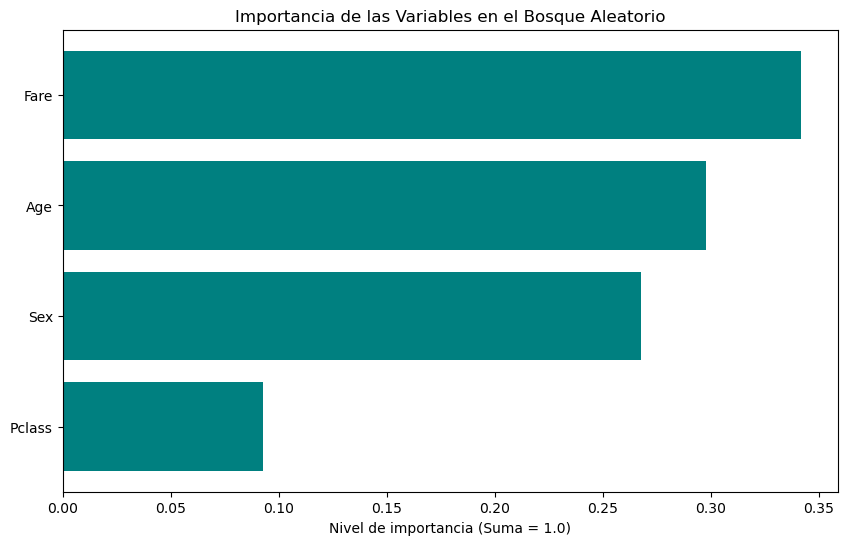

In [32]:
df_imp = df_imp.sort_values(by='Importancia', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(df_imp['Variable'], df_imp['Importancia'], color='teal')
plt.title('Importancia de las Variables en el Bosque Aleatorio')
plt.xlabel('Nivel de importancia (Suma = 1.0)')
plt.show()

Dado que las vairiables de embarked, parch y sibsp no tienen apenas importancia, voy a quitarlas del medio

In [33]:
df_num = df_num[['Fare', 'Age', 'Sex', 'Pclass']]

### Fase de reonocimiento visual

In [34]:
import pandas as pd

# Creamos un DataFrame vacío y le metemos solo las dos cosas que nos importan
df_err = pd.DataFrame()
df_err['Surviv_verdadero'] = y_test
df_err['Prediccion_modelo'] = y_hat_rf

# Filtrar los errores
falsos_positivos = df_err[(df_err['Prediccion_modelo'] == 1) & (df_err['Surviv_verdadero'] == 0)]
display(falsos_positivos.head())

,Surviv_verdadero,Prediccion_modelo
14,0,1
28,0,1
64,0,1
79,0,1
105,0,1


# 3. Construcción de un XGBoost